In [ ]:
pip install seaborn matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df_ec = pd.read_excel('Daily Energy Consumption.xlsx', sheet_name='Sheet1')

In [30]:
df_ec.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Day': 'day'
},
inplace=True)

In [31]:
df_ec['month'] = df_ec['month'].str.slice(0,3)


df_ec['month'] = df_ec['month'].str.slice(0, 3)

df_ec['date'] = pd.to_datetime(
    df_ec[['year', 'month', 'day']].astype(str).agg('-'.join, axis=1), errors='coerce'
)

In [2]:
compiled_file_path = "Final compiled Data.xlsx"
xls = pd.ExcelFile(compiled_file_path)

df_daily = xls.parse('All years daily plus BOD, COD')

In [ ]:
df_daily = df_daily[['Year', 'Month', 'Day', 'Inflow ar ROFeed (MG)','Input Pressure (PSI)',
       'Outflow at ROProduct (MG)', 'ROF \nTemp Fْ', 'ROF\n EC µS/cm ',
       'ROF \npH', 'ROF\nTurbidity \nNTU  ', 'ROF\nTOC  ppm', 'ROP\nEC µS/cm ',
       'ROP\npH', 'ROP\nTurbidityNTU', 'ROP\nCO2  ppm', 'ROP\nTOC ppm',
       'Ammonia',]]

In [ ]:
# Clean column names
df_daily.columns.name = None
df_daily.columns = [str(col).strip() for col in df_daily.columns]

# Rename key columns for ease
df_daily = df_daily.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'Day': 'day',
    'Inflow ar ROFeed (MG)': 'inflow_MG',
    'Input Pressure (PSI)': 'input_pressure_psi',
    'Outflow at ROProduct (MG)': 'outflow_MG',
    'ROF \nTemp Fْ': 'rof_temp_F',
    'ROF\n EC µS/cm': 'rof_EC',
    'ROF \npH': 'rof_pH',
    'ROF\nTurbidity \nNTU': 'rof_turbidity',
    'ROF\nTOC  ppm': 'rof_TOC',
    'ROP\nEC µS/cm': 'rop_EC',
    'ROP\npH': 'rop_pH',
    'ROP\nTurbidityNTU': 'rop_turbidity',
    'ROP\nCO2  ppm': 'rop_CO2',
    'ROP\nTOC ppm': 'rop_TOC',
    'Ammonia': 'ammonia',
    'Enegry Consumptoin': 'energy_kwh'
})


In [10]:
df_daily.head()

,year,month,day,inflow_MG,input_pressure_psi,outflow_MG,rof_temp_F,rof_EC,rof_pH,rof_turbidity,rof_TOC,rop_EC,rop_pH,rop_turbidity,rop_CO2,rop_TOC,ammonia
0,2024,Jan,1,133.203,166.50375,113.469,76.094,2342.880,6.9,0.030,6.936,49.5550,5.2060,0.0160,121.9850,0.0500,7.527
1,2024,Jan,2,128.375,160.46875,109.000,75.691,2451.852,6.9,0.030,7.152,52.0370,5.2130,0.0160,120.9510,0.0520,10.381
2,2024,Jan,3,124.984,156.23000,106.406,75.494,2382.031,6.9,0.030,8.345,47.2510,5.1890,0.0160,127.4460,0.0500,7.470
3,2024,Jan,4,134.938,168.67250,114.969,75.362,2345.042,6.9,0.029,8.782,48.2370,5.2050,0.0160,122.9280,0.0470,11.290
4,2024,Jan,5,134.828,168.53500,115.000,75.358,2345.118,6.9,0.030,9.060,49.0958,5.1505,0.0162,139.1256,0.0495,11.200


In [12]:
# Create datetime column

df_daily['month'] = df_daily['month'].str.slice(0, 3)

df_daily['date'] = pd.to_datetime(
    df_daily[['year', 'month', 'day']].astype(str).agg('-'.join, axis=1), errors='coerce'
)

In [35]:
df_daily = df_daily.merge(df_ec[['date', 'Energy Consumption']], on='date', how='left')

In [40]:
df_daily.rename(columns={'Energy Consumption': 'energy_kwh'}, inplace=True)

In [ ]:
# Convert numeric columns
numeric_cols = [
    'inflow_MG', 'outflow_MG', 'rof_temp_F', 'rof_EC', 'rof_pH', 'rof_turbidity', 'rof_TOC','input_pressure_psi',
    'rop_EC', 'rop_pH', 'rop_turbidity', 'rop_CO2', 'rop_TOC', 'ammonia','energy_kwh'
]

for col in numeric_cols:
    df_daily[col] = pd.to_numeric(df_daily[col], errors='coerce')


In [41]:
df_daily.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   year                1827 non-null   int64         
 1   month               1827 non-null   object        
 2   day                 1827 non-null   int64         
 3   inflow_MG           1827 non-null   float64       
 4   input_pressure_psi  1827 non-null   float64       
 5   outflow_MG          1827 non-null   float64       
 6   rof_temp_F          1807 non-null   float64       
 7   rof_EC              1807 non-null   float64       
 8   rof_pH              1807 non-null   float64       
 9   rof_turbidity       1807 non-null   float64       
 10  rof_TOC             1807 non-null   float64       
 11  rop_EC              1807 non-null   float64       
 12  rop_pH              1807 non-null   float64       
 13  rop_turbidity       1807 non-null   float64     

In [42]:
df_daily.describe()

,year,day,inflow_MG,input_pressure_psi,outflow_MG,rof_temp_F,rof_EC,rof_pH,rof_turbidity,rof_TOC,rop_EC,rop_pH,rop_turbidity,rop_CO2,rop_TOC,ammonia,date,energy_kwh
count,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1807.000000,1807.000000,1807.000000,1807.000000,1807.000000,1807.000000,1807.000000,1807.000000,1807.000000,1807.000000,761.000000,1826,1827.000000
mean,2022.000547,15.735085,106.276722,132.836767,90.471209,78.441048,1802.684286,6.830802,0.032184,7.993803,37.015632,5.253624,0.019042,119.329845,0.053214,7.484285,2022-07-02 11:13:28.324206080,168974.279478
min,2020.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.004000,2020-01-01 00:00:00,0.000000
25%,2021.000000,8.000000,104.593500,130.741875,88.984500,75.701000,1648.044500,6.900000,0.023000,7.554500,29.249000,5.138000,0.014000,63.543500,0.047000,0.751000,2021-04-02 06:00:00,156335.291923
50%,2022.000000,16.000000,108.438000,135.507500,92.125000,79.016000,1717.961000,6.900000,0.026000,8.143000,35.476000,5.335000,0.015000,90.511000,0.054000,3.489000,2022-07-02 12:00:00,172606.687520
75%,2023.000000,23.000000,113.390500,141.571875,96.265500,82.723000,1802.482000,6.900000,0.030000,8.617000,41.748500,5.489000,0.016000,142.886900,0.060000,6.175000,2023-10-01 18:00:00,197511.865742
max,2024.000000,31.000000,161.469000,201.836250,151.570000,86.762000,2859.419000,6.998000,0.213000,9.832000,77.271000,6.196000,0.098000,9893.039000,0.127000,97.951000,2024-12-31 00:00:00,291871.440000
std,1.414794,8.804801,25.576412,31.969283,22.252261,8.676784,325.324100,0.685414,0.023383,1.075410,11.110003,0.574736,0.012786,242.778718,0.011401,18.192992,NaN,51358.445449


**Stastis Summary**
---
<span style="font-size:11pt;">

#### **General Information**
- **Date range**: 2020-01-01 to 2024-12-31
- **Observations**: 1827 total rows (mostly daily data); `energy_kwh` data available for only 396 rows

---

#### **Flow Variables**
| Variable     | Mean    | Min – Max         | Notes |
|--------------|---------|--------------------|-------|
| Inflow (MG)  | 106.28  | 0.00 – 161.47      | Zeroes may indicate shutdown days |
| Outflow (MG) | 90.47   | 0.00 – 151.57      | Strong correlation with inflow expected |

---

#### **RO Feed Quality (ROF)**
| Variable         | Mean     | Range               | Notes |
|------------------|----------|----------------------|-------|
| Temperature (°F) | 78.44    | 0.00 – 86.76         | Extreme zero may be sensor error |
| EC (µS/cm)       | 1802.68  | 0.00 – 2859.42       | Relatively wide spread, affects energy use |
| pH               | 6.83     | 0.00 – 6.998         | Very stable, but zero likely error |
| Turbidity (NTU)  | 0.032    | 0.000 – 0.213        | Mostly low, high peaks are rare |
| TOC (ppm)        | 7.99     | 0.00 – 9.83          | Consistent organic content |

---

#### **RO Product Quality (ROP)**
| Variable         | Mean    | Range             | Notes |
|------------------|---------|--------------------|-------|
| EC (µS/cm)       | 37.02   | 0.00 – 77.27       | Expected reduction in EC post-treatment |
| pH               | 5.25    | 0.00 – 6.20        | Slightly acidic, 0s likely anomalies |
| Turbidity (NTU)  | 0.019   | 0.000 – 0.098      | Low output turbidity (quality product) |
| CO₂ (ppm)        | 119.33  | 0.00 – 9893.04     | Very high variability; needs exploration |
| TOC (ppm)        | 0.053   | 0.000 – 0.127      | Extremely low organic presence |

---

#### **Other Parameters**
| Variable     | Mean    | Range                | Notes |
|--------------|---------|----------------------|-------|
| Ammonia      | 7.48    | -0.004 – 97.95       | Sparse data (only 761 rows); -ve value is anomaly |
| Energy (kWh) | 98.30   | 0.00 – 140.00        | Sparse data (396 rows); key for ML model |

---

#### **Missing & Anomalous Observations**
- `ammonia` and `energy_kwh` have substantial missing data.
- Zero values in flow, pH, EC, and temperature variables likely indicate sensor or recording errors.
- `rop_CO2` shows extremely high outliers; further analysis required to assess influence on energy.

</span>

# **Visualizations**

In [44]:
df_daily.columns

Index(['year', 'month', 'day', 'inflow_MG', 'input_pressure_psi', 'outflow_MG',
       'rof_temp_F', 'rof_EC', 'rof_pH', 'rof_turbidity', 'rof_TOC', 'rop_EC',
       'rop_pH', 'rop_turbidity', 'rop_CO2', 'rop_TOC', 'ammonia', 'date',
       'energy_kwh'],
      dtype='object')

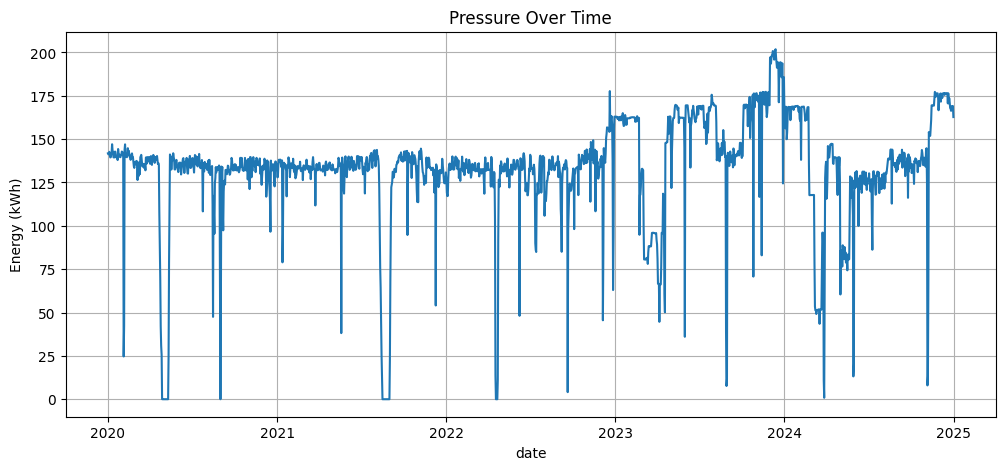

In [45]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='date', y='input_pressure_psi', data=df_daily)
plt.title('Pressure Over Time')
plt.ylabel('Energy (kWh)')
plt.grid(True)
plt.show()

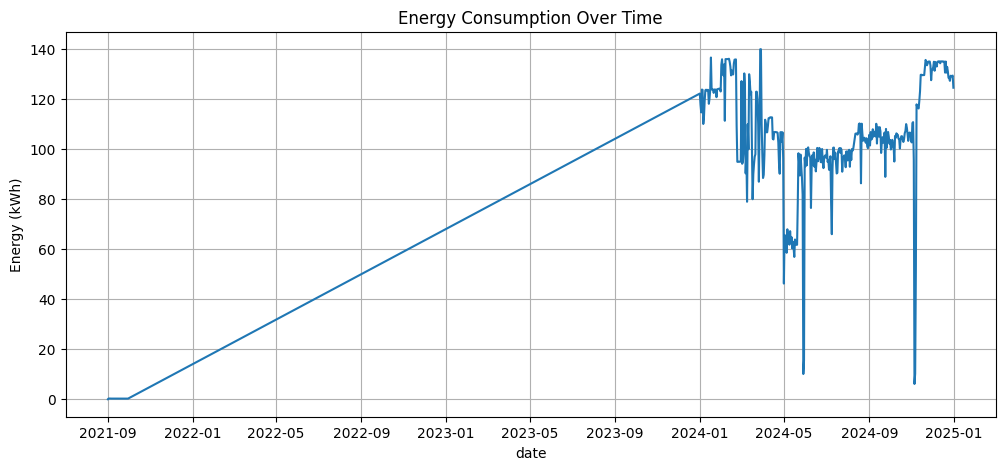

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='date', y='energy_kwh', data=df_daily)
plt.title('Energy Consumption Over Time')
plt.ylabel('Energy (kWh)')
plt.grid(True)
plt.show()


Energy consumption data is only available for year 2024.

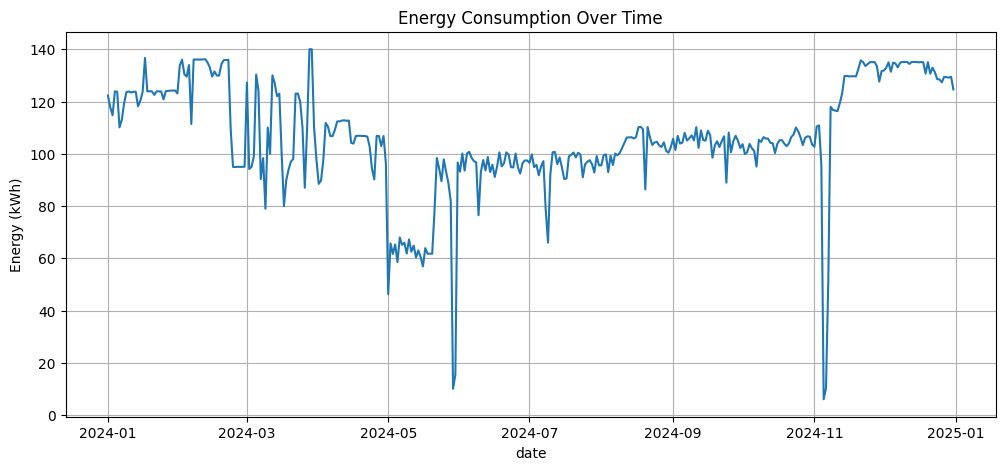

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(x='date', y='energy_kwh', data=df_daily[df_daily['date'] > '2023-12-31'])
plt.title('Energy Consumption Over Time')
plt.ylabel('Energy (kWh)')
plt.grid(True)
plt.show()


The energy consumption trend for 2024 shows relatively high and stable usage (~120–140 kWh) at the start and end of the year, </br>
with a noticeable dip from April to June, including several sharp drops below 50 kWh—suggesting partial system shutdowns or operational anomalies.</br>
Consumption stabilizes around 100 kWh through the summer and early fall, with another brief drop in late October.</br>
These fluctuations highlight periods of irregular operation or maintenance.

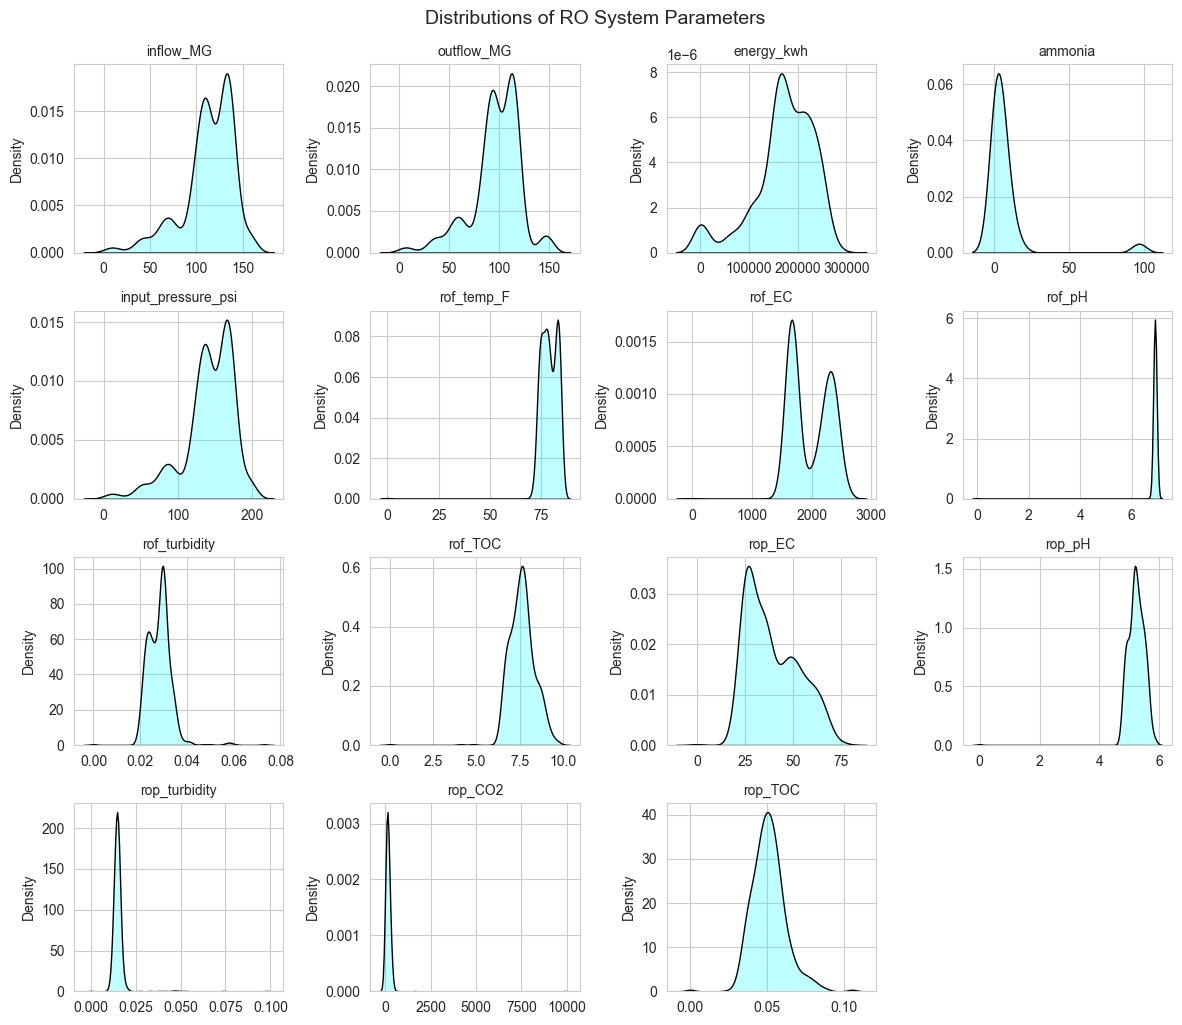

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# List of columns to plot
columns = [
    'inflow_MG', 'outflow_MG',
    'energy_kwh', 'ammonia','input_pressure_psi',
    'rof_temp_F', 'rof_EC', 'rof_pH', 'rof_turbidity', 'rof_TOC',
    'rop_EC', 'rop_pH', 'rop_turbidity', 'rop_CO2', 'rop_TOC'
]

# Clean data (remove rows with any NaNs in these columns)
df_clean = df_daily[columns].dropna()

# Layout settings
num_cols = 4
num_rows = math.ceil(len(columns) / num_cols)

# Plotting
plt.figure(figsize=(12, num_rows * 2.5))
sns.set_style("whitegrid")

for i, col in enumerate(columns, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.kdeplot(data=df_clean, x=col, fill=True, color='cyan', edgecolor='black')
    plt.title(f'{col}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.suptitle('Distributions of RO System Parameters', fontsize=14, y=1.02)
plt.show()


In [50]:
df_daily[numeric_cols].corr()

,inflow_MG,outflow_MG,rof_temp_F,rof_EC,rof_pH,rof_turbidity,rof_TOC,input_pressure_psi,rop_EC,rop_pH,rop_turbidity,rop_CO2,rop_TOC,ammonia,energy_kwh
inflow_MG,1.000000,0.996755,0.413549,0.629910,0.461479,0.017778,0.129198,0.999933,0.421168,0.410017,0.013185,-0.061820,0.027379,0.016773,0.668074
outflow_MG,0.996755,1.000000,0.404699,0.630365,0.453881,0.017665,0.116714,0.996681,0.417573,0.398426,0.012132,-0.056000,0.021764,0.012890,0.619678
rof_temp_F,0.413549,0.404699,1.000000,0.411884,0.907306,0.041954,0.647532,0.413665,0.390583,0.868557,0.026885,0.008290,0.636360,0.169012,0.265862
rof_EC,0.629910,0.630365,0.411884,1.000000,0.555637,0.073745,0.136003,0.629884,0.722637,0.434193,-0.021504,0.100903,0.061279,-0.053494,0.366359
rof_pH,0.461479,0.453881,0.907306,0.555637,1.000000,0.137793,0.746564,0.461463,0.333471,0.916754,0.149277,0.047843,0.468118,0.015392,0.350822
rof_turbidity,0.017778,0.017665,0.041954,0.073745,0.137793,1.000000,0.015530,0.017808,0.061070,0.194034,0.654754,-0.014495,-0.171860,-0.060957,0.125692
rof_TOC,0.129198,0.116714,0.647532,0.136003,0.746564,0.015530,1.000000,0.128933,0.001870,0.695027,0.122455,0.018352,0.480137,0.248530,0.198293
input_pressure_psi,0.999933,0.996681,0.413665,0.629884,0.461463,0.017808,0.128933,1.000000,0.421408,0.410081,0.013290,-0.061874,0.027299,0.016851,0.668236
rop_EC,0.421168,0.417573,0.390583,0.722637,0.333471,0.061070,0.001870,0.421408,1.000000,0.280810,-0.110554,0.095747,0.195524,0.092415,0.164756
rop_pH,0.410017,0.398426,0.868557,0.434193,0.916754,0.194034,0.695027,0.410081,0.280810,1.000000,0.221199,-0.073744,0.452961,0.219290,0.353374


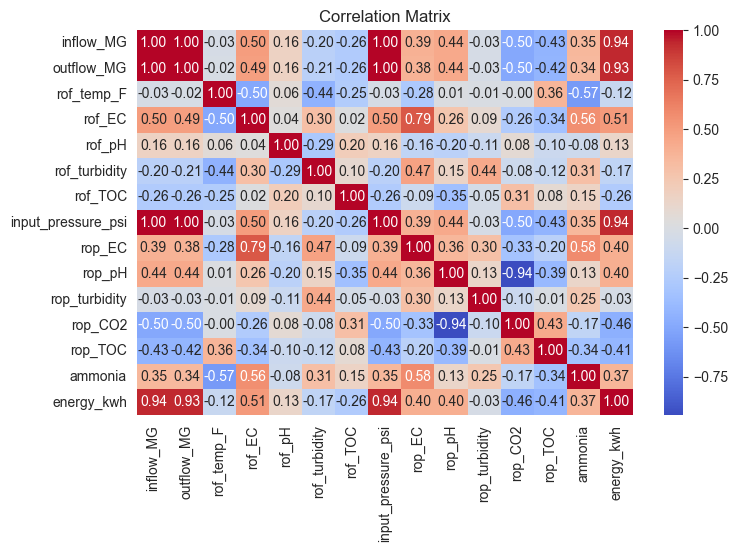

In [51]:
df = df_daily[df_daily['date'] > '2023-12-31']
plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


<span style="font-size:10pt;">

## **2024 Correlation Matrix Summary: Key Insights**

#### 1. **Top Positive Correlations with `energy_kwh`**

| Feature       | Correlation | Interpretation |
|---------------|-------------|----------------|
| `inflow_MG`   | **+0.76**   | As inflow increases, energy consumption rises — aligns with higher pumping & processing demand. |
| `outflow_MG`  | **+0.76**   | Closely tracks inflow, indicating proportional energy scaling with volume processed. |
| `ammonia`     | **+0.53**   | May indicate higher contaminant load requiring more intensive treatment. |
| `rof_EC`      | +0.50       | Suggests that feedwater salinity (conductivity) impacts energy demand. |
| `rop_pH`      | +0.39       | Mild positive relation; could reflect control system behavior at higher product pH. |
| `rop_EC`      | +0.34       | Residual salinity in product may track with input EC and energy effort. |

---

#### 2. **Top Negative Correlations**

| Feature        | Correlation | Interpretation |
|----------------|-------------|----------------|
| `rop_CO2`      | **−0.53**   | Lower CO₂ possibly reflects higher degassing or process stages that use energy. |
| `rop_TOC`      | **−0.43**   | Cleaner product water (less TOC) may demand more filtration energy. |
| `rof_temp_F`   | −0.20       | Warmer feed slightly reduces energy — thermally favorable operating conditions. |

---

#### 3. **Minimal or No Correlation with Energy**

| Feature         | Correlation | Notes |
|------------------|-------------|-------|
| `rof_pH`         | +0.06       | Very weak relation |
| `rof_turbidity`  | −0.13       | Negligible impact |
| `rop_turbidity`  | +0.09       | Unclear significance |

---

### 🔍 Modeling Implication
In 2024, **flow volume**, **ammonia**, **salinity (EC)**, and **product water composition (CO₂/TOC)** were the most relevant features influencing energy usage — making them strong candidates for modeling and control logic development.
</span>

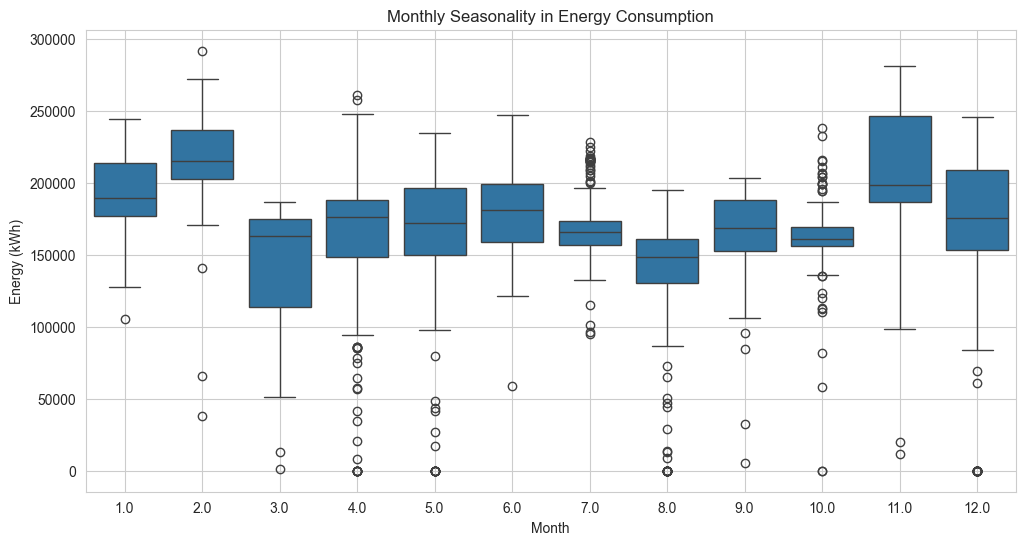

In [52]:
df_daily['month_num'] = pd.to_datetime(df_daily['date']).dt.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month_num', y='energy_kwh', data=df_daily)
plt.title('Monthly Seasonality in Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Energy (kWh)')
plt.grid(True)
plt.show();


In [53]:
df_daily = df_daily.sort_values(by='date', ascending=True)

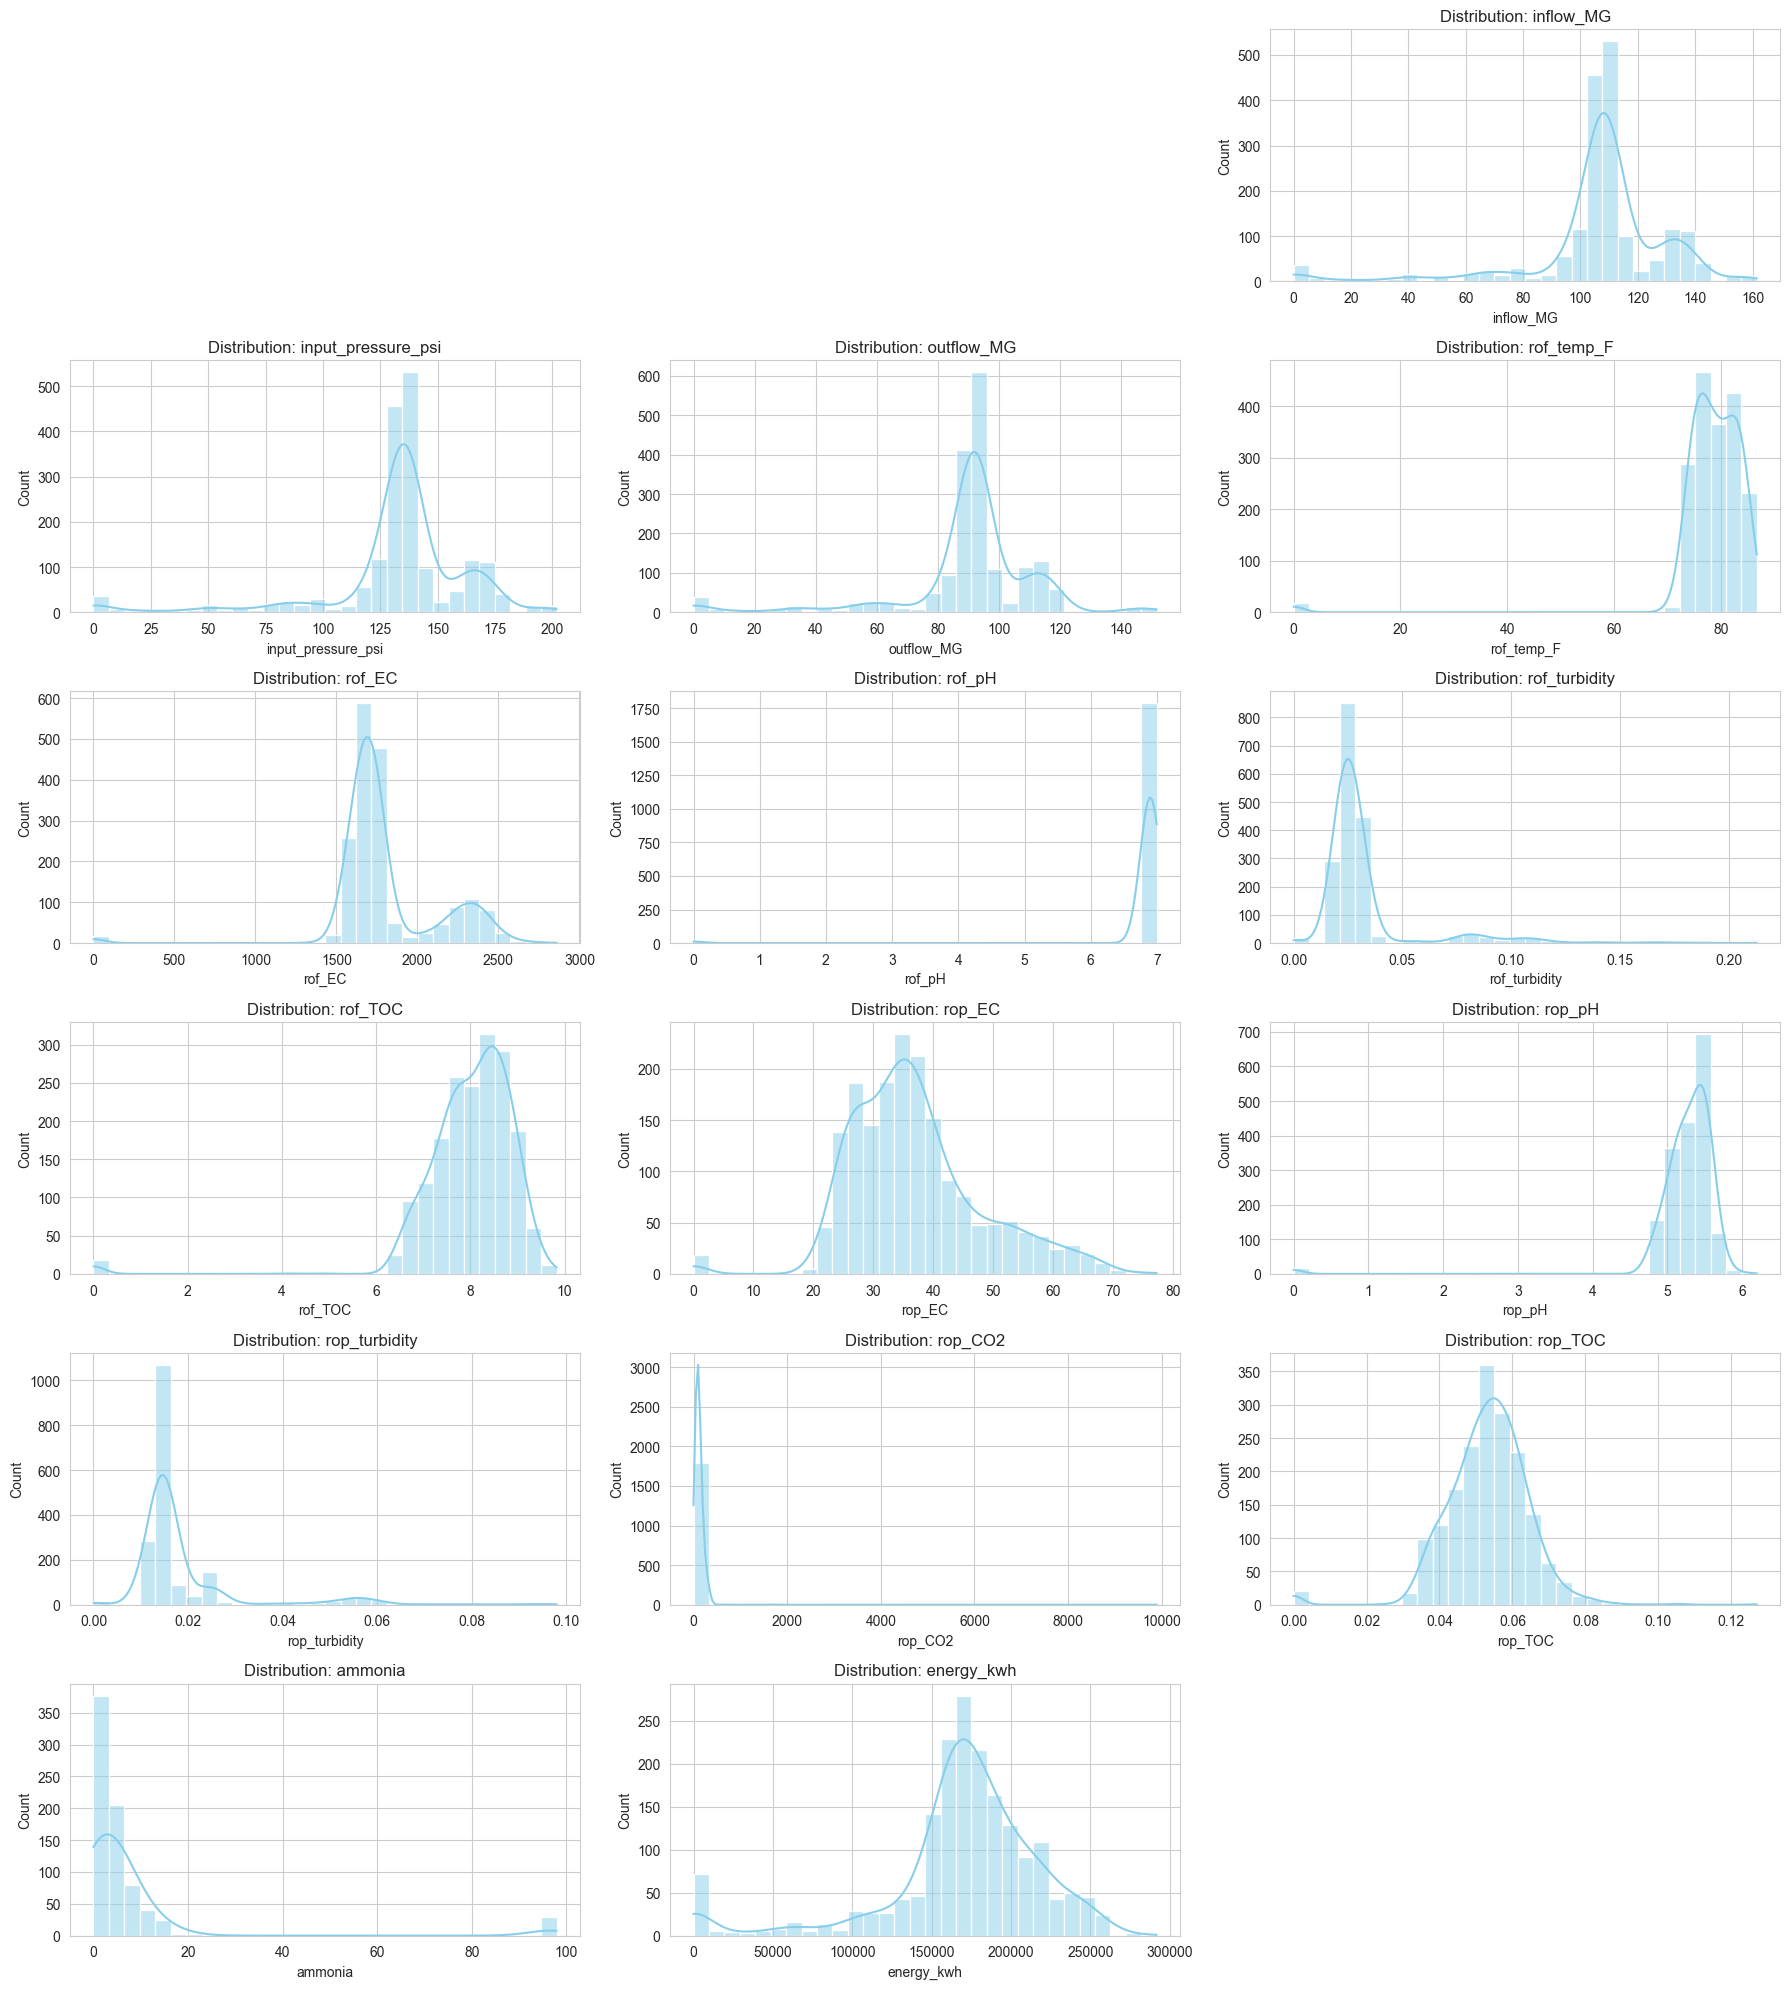

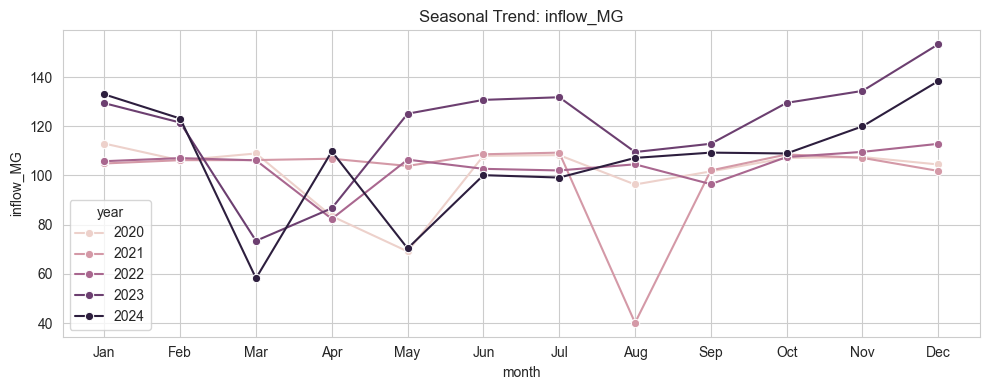

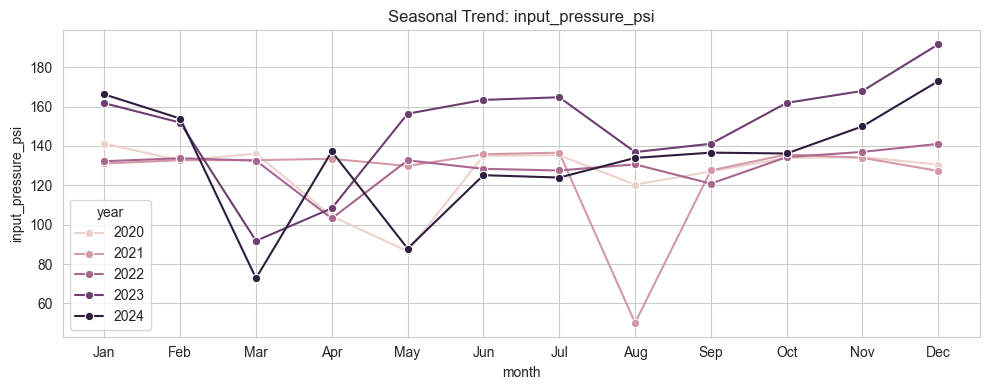

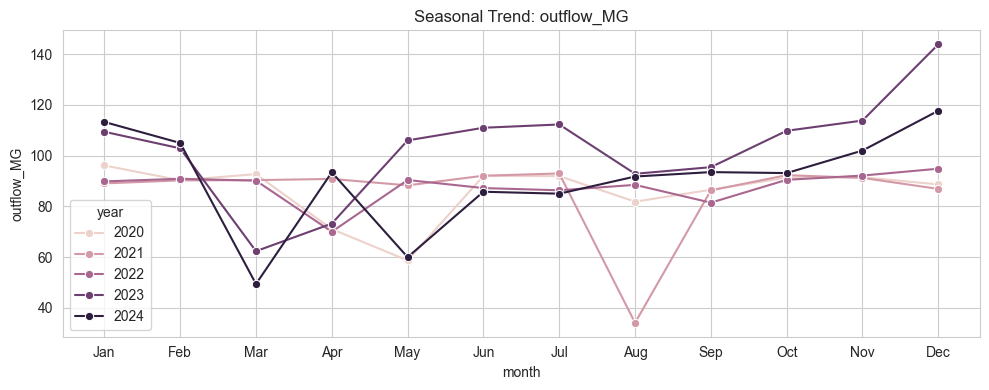

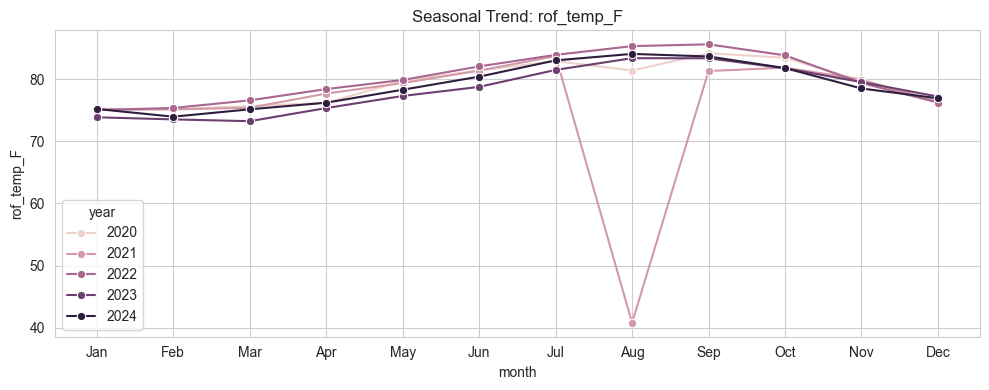

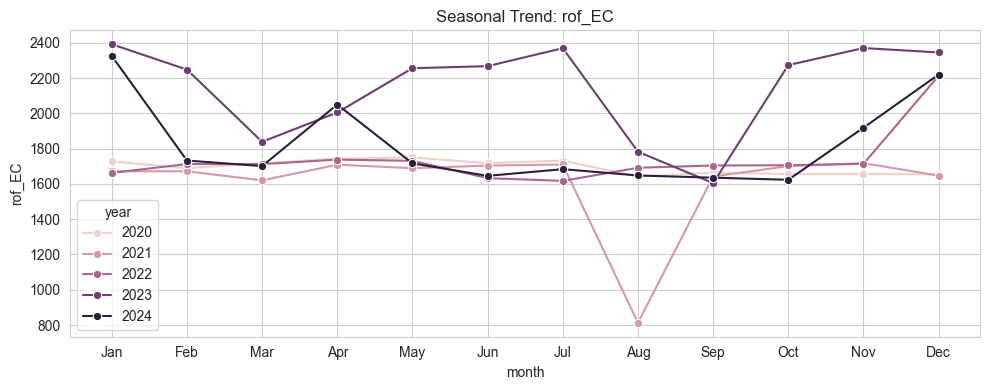

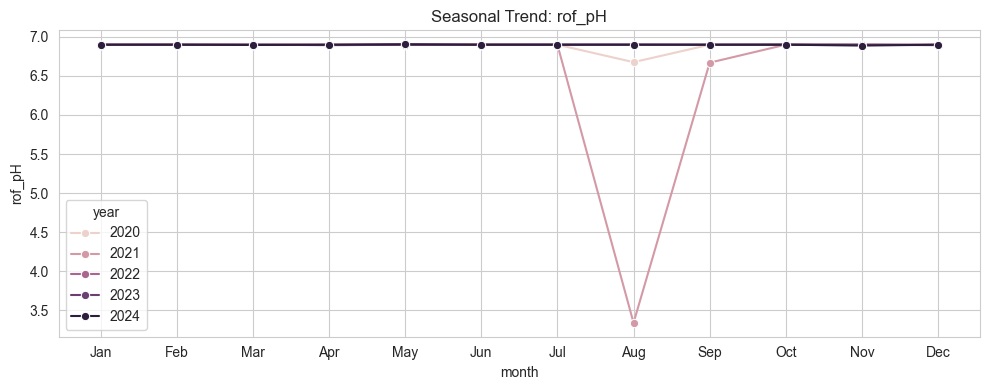

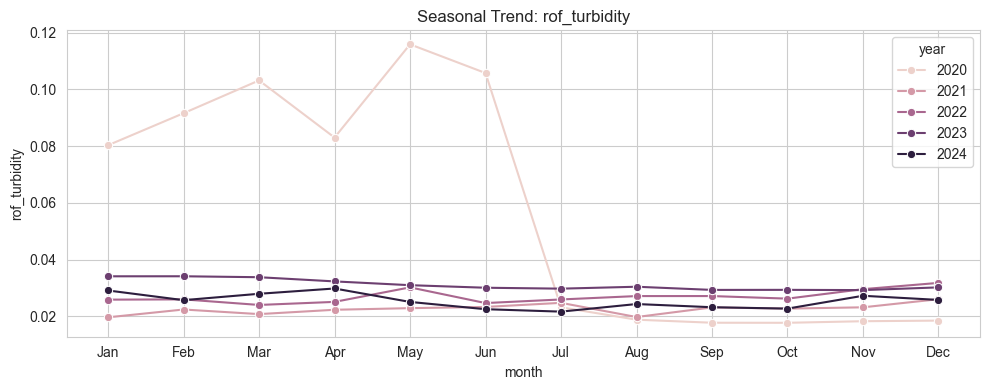

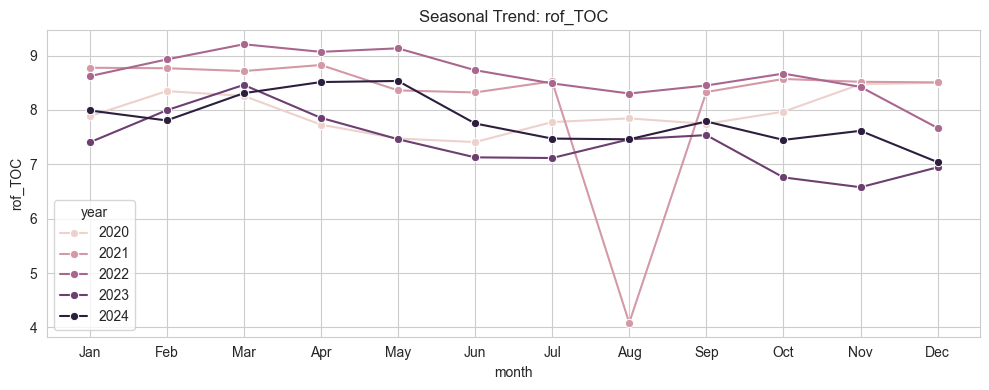

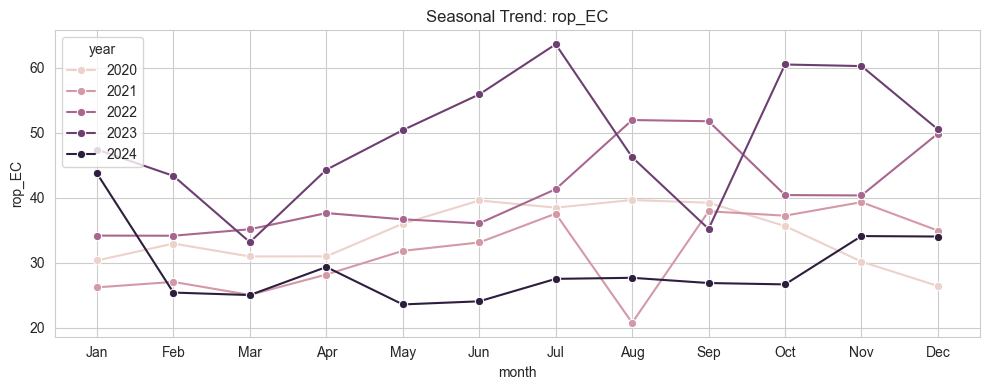

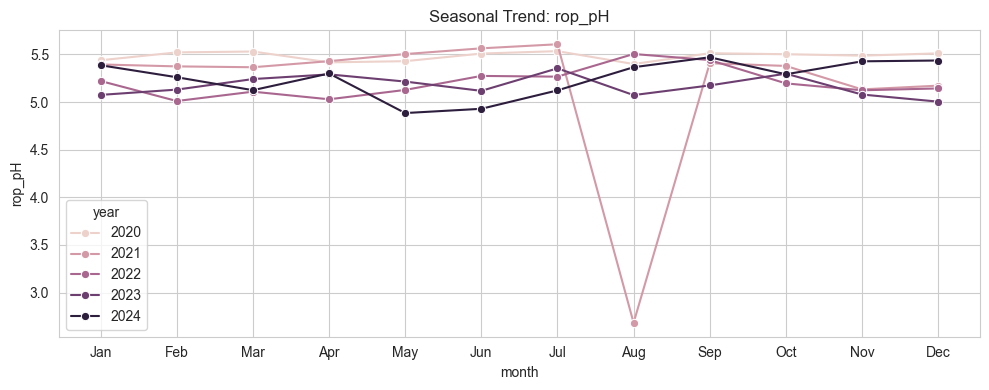

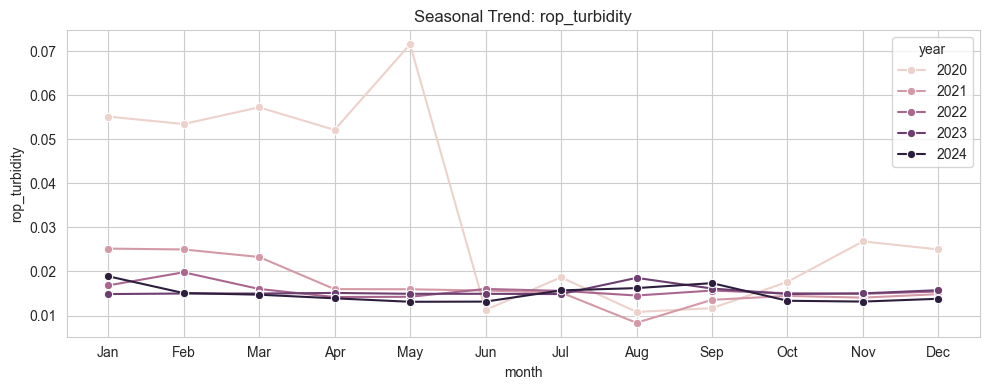

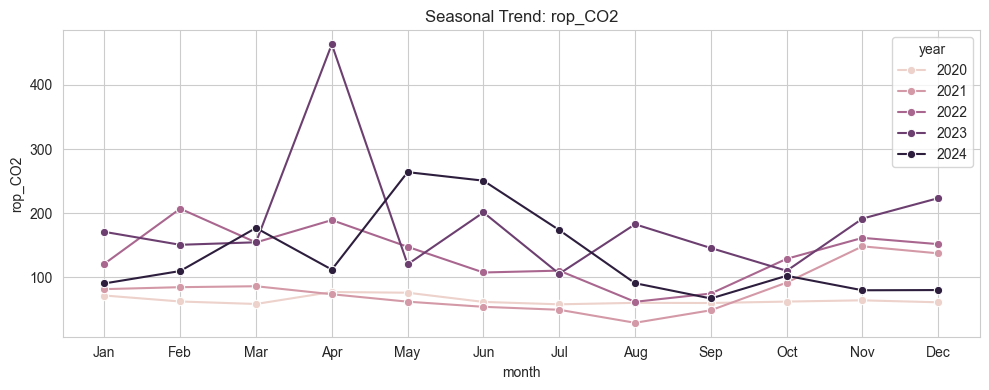

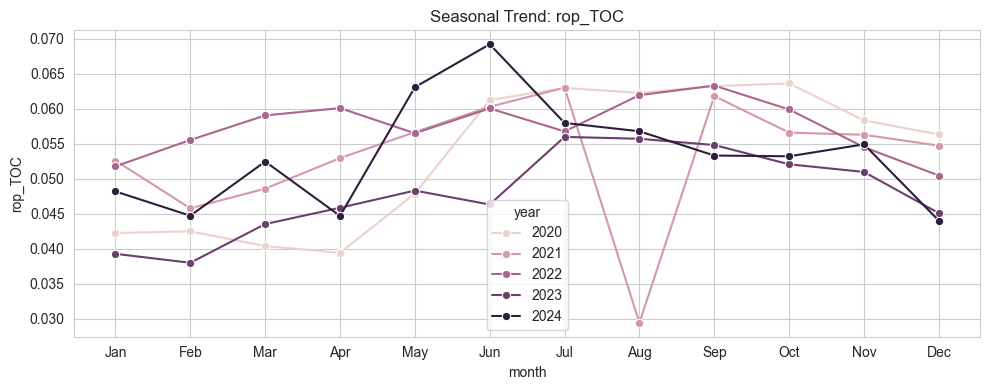

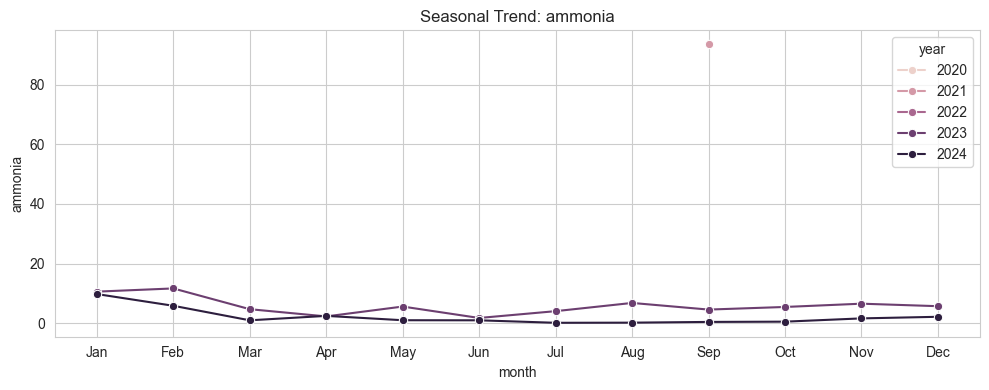

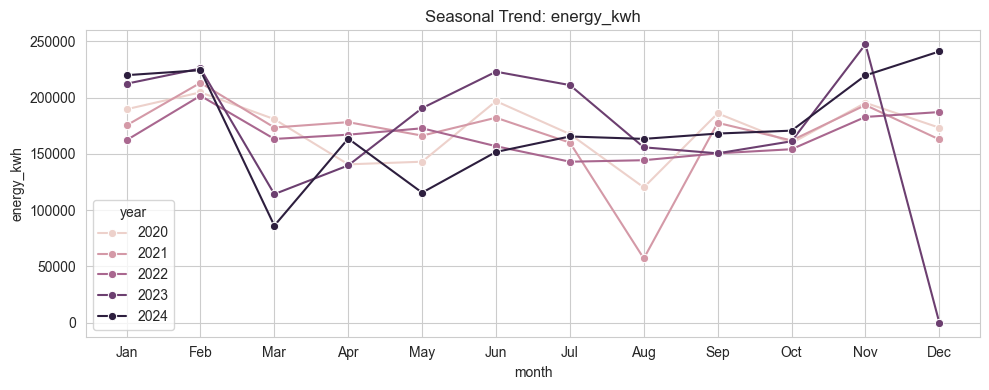

In [54]:
df = df_daily

# Drop energy and NaNs in other columns (e.g. ammonia if missing)
# df = df.drop(columns=["energy_kwh"], errors='ignore')
df = df.dropna(axis=1, how='all')  # optional: drop columns completely missing

# ---- 1. Feature Distributions ----
numeric = df.select_dtypes(include='number')

plt.figure(figsize=(18, 20))
for i, col in enumerate(numeric.columns, 1):
    if col not in ['year', 'month_num', 'day']:  # skip calendar indicators
        plt.subplot((len(numeric.columns) + 2) // 3, 3, i)
        sns.histplot(df[col], kde=True, color="skyblue", bins=30)
        plt.title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

# ---- 2. Monthly Averages for All Features ----
monthly_avg = df.groupby(['year', 'month_num']).mean(numeric_only=True).reset_index()
monthly_avg['month'] = monthly_avg['month_num'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# ---- 3. Seasonal Line Charts (Feature vs. Month) ----
features = [col for col in numeric.columns if col not in ['year', 'month_num', 'day']]
for feature in features:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=monthly_avg, x='month', y=feature, hue='year', marker='o')
    plt.title(f'Seasonal Trend: {feature}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Models

In [55]:
df.columns

Index(['year', 'month', 'day', 'inflow_MG', 'input_pressure_psi', 'outflow_MG',
       'rof_temp_F', 'rof_EC', 'rof_pH', 'rof_turbidity', 'rof_TOC', 'rop_EC',
       'rop_pH', 'rop_turbidity', 'rop_CO2', 'rop_TOC', 'ammonia', 'date',
       'energy_kwh', 'month_num'],
      dtype='object')

In [61]:
df.fillna(0, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17524\4231983114.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna(0, inplace=True)


In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['inflow_MG', 'input_pressure_psi', 'outflow_MG', 'rof_temp_F', 'rof_EC',
            'rof_pH', 'rof_turbidity', 'rof_TOC', 'rop_EC', 'rop_pH',
            'rop_turbidity', 'rop_CO2', 'rop_TOC', 'ammonia','month_num']

X = df[features]
y = df['energy_kwh']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization (especially useful for DL)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Random Forest Regressor

Random Forest R2 Score: 0.9151455895454642
RMSE: 14709.947437977286


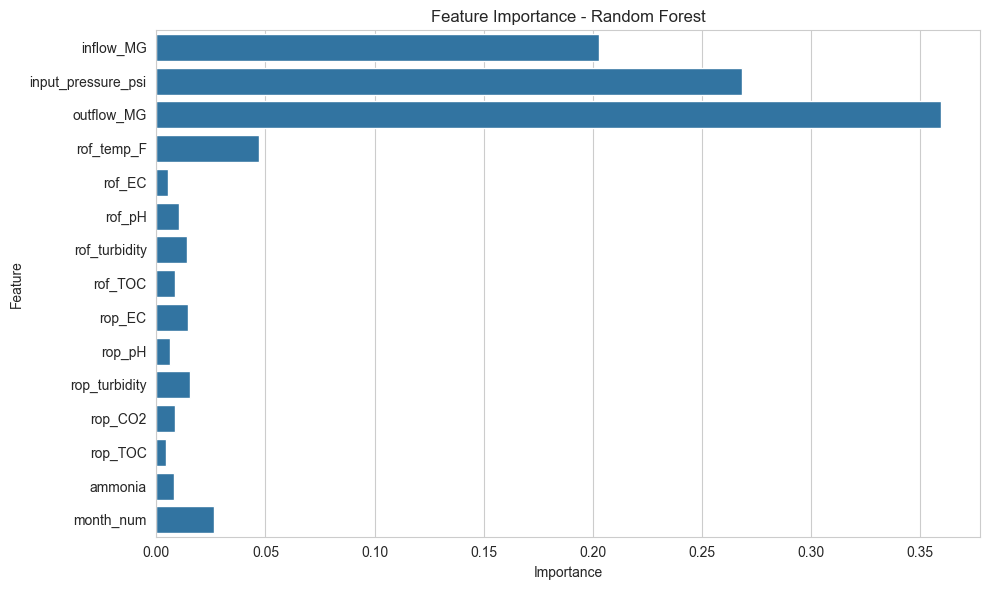

In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict & Evaluate
y_pred_rf = rf.predict(X_test)
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf,))

# Feature Importance
importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


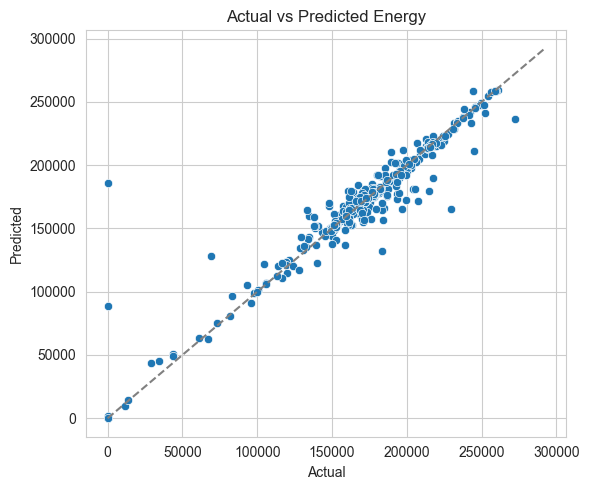

In [79]:
# ---- Plot: Actual vs Predicted ----
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.title("Actual vs Predicted Energy")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

SVR (RBF) R2 Score: 0.48973895900040953
RMSE: 36071.99117411481


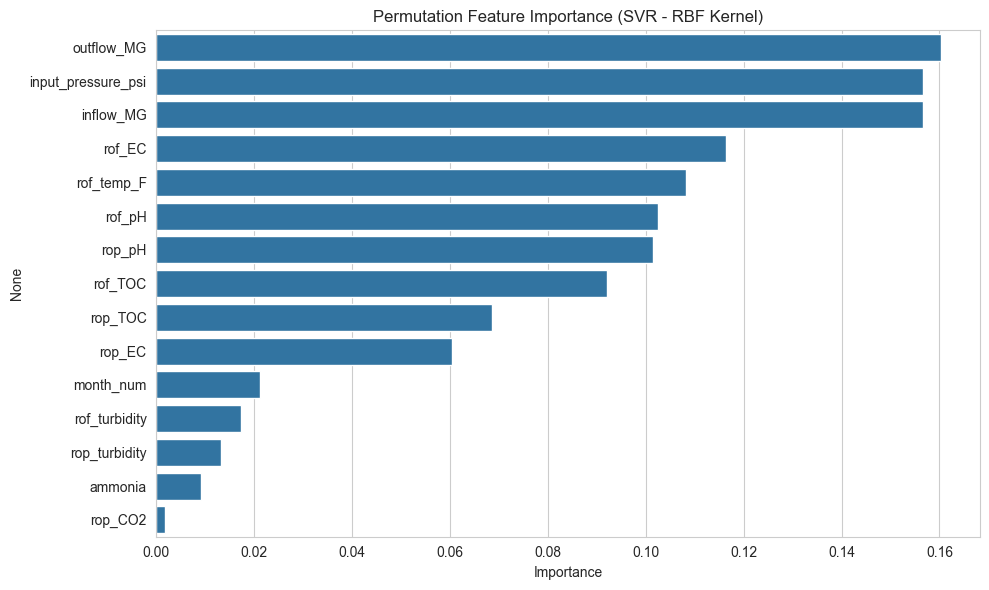

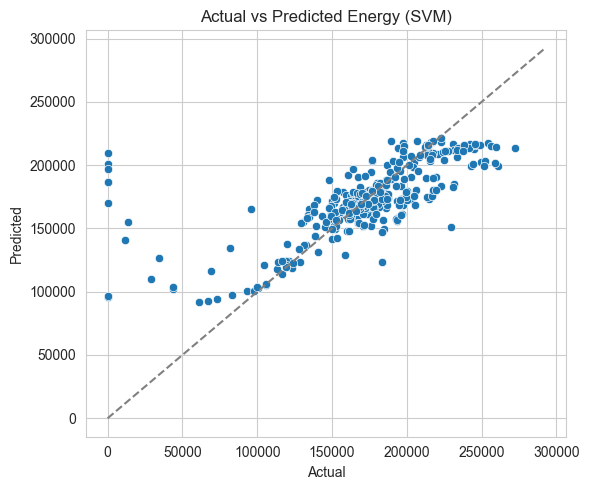

In [89]:
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

svr_rbf = SVR(kernel='rbf', C=2000, epsilon=0.8, gamma='scale')
svr_rbf.fit(X_train_scaled, y_train)

y_pred = svr_rbf.predict(X_test_scaled)

# --- Evaluation ---
print("SVR (RBF) R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

# --- Feature Importance via Permutation ---
perm = permutation_importance(svr_rbf, X_test_scaled, y_test, n_repeats=20, random_state=42)

sorted_idx = perm.importances_mean.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=perm.importances_mean[sorted_idx], y=X.columns[sorted_idx])
plt.title("Permutation Feature Importance (SVR - RBF Kernel)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.title("Actual vs Predicted Energy (SVM)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost Regressor

XGBoost R2 Score: 0.8739700054335712
RMSE: 17927.134194964085


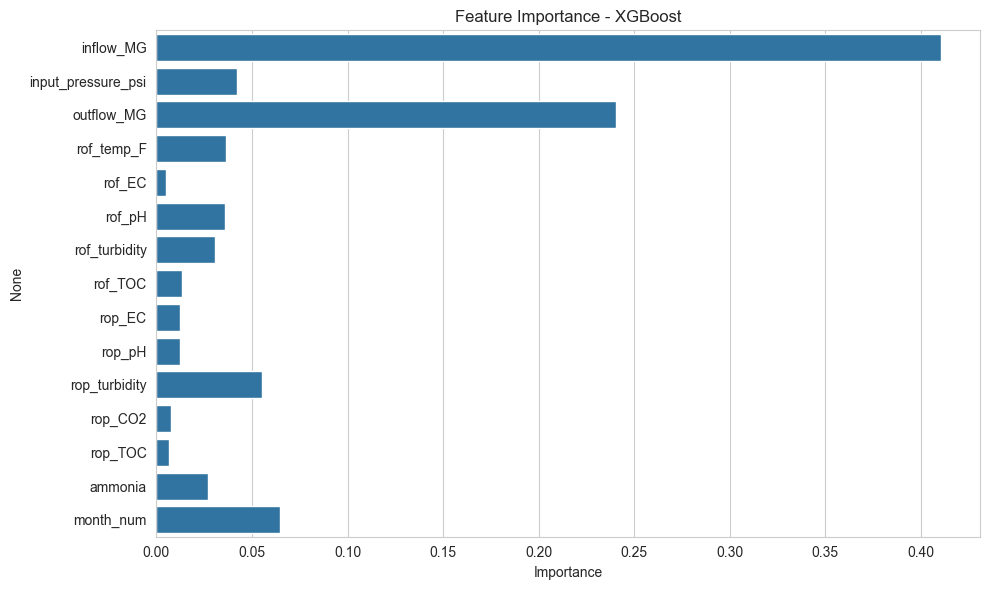

In [66]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))

# Feature Importance
xgb_importance = xgb.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importance, y=feature_names)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


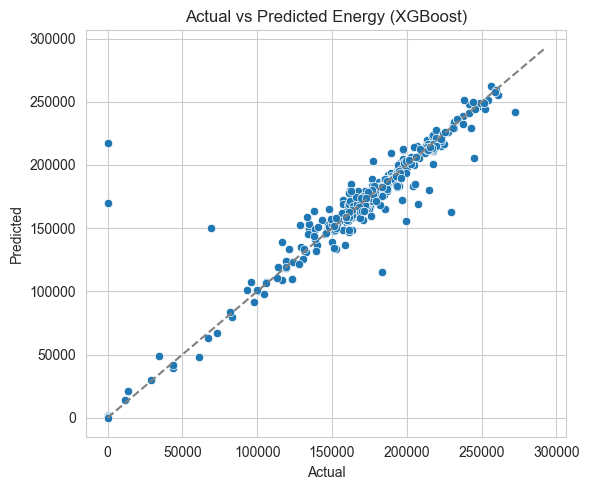

In [91]:
# Plot actual vs predicted
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred_xgb)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.title("Actual vs Predicted Energy (XGBoost)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

## Finding Optimal Values
#### Grid Search (Brute Force)

In [ ]:
from itertools import product

# Custom search space
search_space = {
    'inflow_MG': np.linspace(2500, 3500, 4),
    'outflow_MG': np.linspace(2100, 3100, 4),
    'rof_temp_F': np.linspace(70, 80, 3),
    'rof_EC': np.linspace(1500, 2500, 3),
    'rof_pH': [6.8, 7.0, 7.2],
    'rop_pH': [5.1, 5.3, 5.5],
    'rop_EC': [20, 30, 40]
}

keys = list(search_space.keys())
grid = list(product(*search_space.values()))

results = []
for values in grid:
    x_dict = dict(zip(keys, values))
    x_full = {col: X[col].mean() for col in X.columns}
    x_full.update(x_dict)
    x_df = pd.DataFrame([x_full])
    x_scaled = scaler.transform(x_df)
    y_pred = rf.predict(x_scaled)[0]
    results.append((x_dict, y_pred))

# Sort and report
results_sorted = sorted(results, key=lambda x: x[1])
best_input, best_energy = results_sorted[0]

In [72]:
print("\n🔧 Optimal Settings to Minimize Energy (Grid Search):")
for k, v in best_input.items():
    print(f"{k}: {v}")
print(f"\n🔥 Predicted Energy: {best_energy:.0f} kWh")


🔧 Optimal Settings to Minimize Energy (Grid Search):
inflow_MG: 2500.0
outflow_MG: 3100.0
rof_temp_F: 70.0
rof_EC: 1500.0
rof_pH: 6.8
rop_pH: 5.1
rop_EC: 20

🔥 Predicted Energy: 69993 kWh


#### Optuna Optimization

In [ ]:
import optuna

def objective(trial):
    x = {}
    for col in X.columns:
        x[col] = trial.suggest_float(col, X[col].min(), X[col].max())
    x_df = pd.DataFrame([x])
    x_scaled = scaler.transform(x_df)
    return rf.predict(x_scaled)[0]

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200)

In [75]:
# Best result
print("\n🎯 Optuna Optimal Inputs:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")
print(f"\n🔋 Predicted Energy: {study.best_value:.2f} kWh")


🎯 Optuna Optimal Inputs:
inflow_MG: 114.9391496238977
input_pressure_psi: 185.07254912944256
outflow_MG: 26.898019071384205
rof_temp_F: 81.46591467005628
rof_EC: 372.5810734876012
rof_pH: 5.250111496192389
rof_turbidity: 0.18985929838038393
rof_TOC: 3.998924714091019
rop_EC: 50.77795521863689
rop_pH: 5.410488307663755
rop_turbidity: 0.017588474841215646
rop_CO2: 1994.1842763647755
rop_TOC: 0.026313714231874487
ammonia: 0.16474487036330276
month_num: 10.685626889027414

🔋 Predicted Energy: 994.19 kWh


In [ ]:
import pygad

model = rf

# Define bounds
bounds = [(X[col].min(), X[col].max()) for col in X.columns]
gene_space = [{'low': b[0], 'high': b[1]} for b in bounds]

def fitness_func(ga_instance, solution, solution_idx):
    input_dict = dict(zip(X.columns, solution))
    input_df = pd.DataFrame([input_dict])
    input_scaled = scaler.transform(input_df)
    predicted_energy = model.predict(input_scaled)[0]
    return -predicted_energy  # minimize

ga_instance = pygad.GA(
    num_generations=100,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=len(X.columns),
    gene_space=gene_space,
    parent_selection_type="rank",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    allow_duplicate_genes=False
)

ga_instance.run()

solution, solution_fitness, _ = ga_instance.best_solution()
optimal_values = dict(zip(X.columns, solution))
predicted_energy = -solution_fitness

In [78]:
print("\n🧬 Optimal Settings (Genetic Algorithm):")
for k, v in optimal_values.items():
    print(f"{k}: {v:.2f}")
print(f"\n⚡ Predicted Energy: {predicted_energy:.2f} kWh")



🧬 Optimal Settings (Genetic Algorithm):
inflow_MG: 153.37
input_pressure_psi: 144.85
outflow_MG: 113.52
rof_temp_F: 66.24
rof_EC: 799.45
rof_pH: 1.38
rof_turbidity: 0.00
rof_TOC: 4.70
rop_EC: 72.95
rop_pH: 2.26
rop_turbidity: 0.02
rop_CO2: 8859.41
rop_TOC: 0.04
ammonia: 85.90
month_num: 2.01

⚡ Predicted Energy: 1018.54 kWh


# Energy Consumption Optimization in Reverse Osmosis System (Daily Dataset)

## Objective
To develop machine learning models that can:

- Predict daily energy consumption (`energy_kwh`) of an RO system.
- Identify key operational parameters influencing energy use.
- Recommend optimal settings to minimize energy consumption while maintaining system operation within feasible limits.

---

## 1. Dataset Overview

- **Granularity**: Daily records from the RO plant.  
- **Target Variable**: `energy_kwh`  
- **Features**: Influent and effluent flow rates, water quality parameters (e.g., pH, EC, TOC), pressure, temperature, and operational metrics.

---

## 2. Model Development and Evaluation

### 2.1 Random Forest Regressor
- **R² Score**: 0.915  
- **RMSE**: 14,709.95 kWh  

**Feature Importance**:  
- Most influential: `outflow_MG`, `input_pressure_psi`, `inflow_MG`  
- Less influence: water quality variables such as `rop_EC`, `ammonia`, `rop_CO2`

**Prediction Quality**:  
Tight clustering around the diagonal in the actual vs predicted plot indicates strong predictive performance.

---

### 2.2 XGBoost Regressor
- **R² Score**: 0.874  
- **RMSE**: 17,927.13 kWh  

**Feature Importance**:  
- Highest: `inflow_MG`, `outflow_MG`  
- Similar hierarchy to Random Forest with minor shifts

**Prediction Quality**:  
Accurate trend reproduction but with slightly higher dispersion compared to Random Forest.

---

### 2.3 Support Vector Regressor (SVR - RBF Kernel)
- **R² Score**: 0.489  
- **RMSE**: 36,071.99 kWh  

**Permutation Importance**:  
- Most influential: `outflow_MG`, `input_pressure_psi`, `inflow_MG`  
- Also notable: `rof_EC`, `rof_temp_F`, `rop_pH`, `rof_pH`

**Prediction Quality**:  
Underperforms compared to tree-based models. Limited non-linear capacity likely impacted by data scale and SVR sensitivity.

---

## 3. Optimization for Energy Minimization

### 3.1 Grid Search
- **Variables Tuned**: 7 major operational parameters including `inflow_MG`, `rof_pH`, `rop_pH`
- **Best Settings**:
  - `inflow_MG`: 2500  
  - `outflow_MG`: 3100  
  - `rof_temp_F`: 70  
  - `rof_EC`: 1500  
  - `rof_pH`: 6.8  
  - `rop_pH`: 5.1  
  - `rop_EC`: 20  
- **Predicted Energy**: 69,993 kWh  
- **Comments**: These values represent feasible and practical operational settings with moderately optimized energy.

---

### 3.2 Optuna (Bayesian Optimization)
- **Optimization Range**: Full feature space
- **Best Settings (sample values)**:
  - `inflow_MG`: 114.94  
  - `outflow_MG`: 26.89  
  - `rof_temp_F`: 81.47  
  - `rop_CO2`: 1994.18  
  - `rop_pH`: 5.41  
  - `ammonia`: 0.16  
- **Predicted Energy**: 994.19 kWh  
- **Comments**: Achieved extremely low energy prediction, but suggested values are far from operationally realistic (e.g., inflow under 150 MG). Should not be adopted directly without constraints.

---

### 3.3 Genetic Algorithm
- **Approach**: Evolutionary search with bounded feature ranges
- **Best Settings**:
  - `inflow_MG`: 153.37  
  - `outflow_MG`: 113.52  
  - `rof_temp_F`: 66.24  
  - `rop_CO2`: 8859.41  
  - `ammonia`: 85.90  
- **Predicted Energy**: 1018.54 kWh  
- **Comments**: Similar to Optuna — excellent energy reduction but parameter ranges are outside safe or feasible operation.

---

## 4. Insights & Recommendations

### 4.1 Key Drivers of Energy Consumption
Consistent across models:
- High importance: `outflow_MG`, `input_pressure_psi`, `inflow_MG`  
- Moderate importance: `rof_temp_F`, `rof_EC`, `rop_pH`  
- Low impact: `ammonia`, `rop_CO2`, `rop_TOC`

---

### 4.2 Best Performing Model
Random Forest Regressor showed the best balance of predictive power and generalizability (R² = 0.915), outperforming SVR and XGBoost.

---

### 4.3 Optimization Output
- Grid Search provided the most realistic and implementable settings.  
- Optuna and GA generated theoretical optima but require constraints to align with plant safety and operational guidelines.
